In [1]:
# Step 1: Load saved project artifacts and Notebook 5 results

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

# 1. Recreate the custom transformer used inside saved preprocessor
# This class must be defined before loading the fitted preprocessor.

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Converts categorical values to strings and groups categories
    occurring fewer than min_frequency times into __RARE__.
    """

    def __init__(
        self,
        min_frequency=10,
        rare_label="__RARE__"
    ):
        self.min_frequency = min_frequency
        self.rare_label = rare_label

    def fit(self, X, y=None):
        X_array = np.asarray(
            X,
            dtype=object
        ).astype(str)

        if X_array.ndim != 2:
            raise ValueError(
                "RareCategoryGrouper expects a two-dimensional input."
            )

        self.n_features_in_ = X_array.shape[1]
        self.frequent_categories_ = []

        for column_index in range(self.n_features_in_):
            category_counts = pd.Series(
                X_array[:, column_index]
            ).value_counts(dropna=False)

            frequent_categories = set(
                category_counts[
                    category_counts >= self.min_frequency
                ].index.tolist()
            )

            self.frequent_categories_.append(
                frequent_categories
            )

        return self

    def transform(self, X):
        check_is_fitted(
            self,
            attributes=["frequent_categories_"]
        )

        X_array = np.asarray(
            X,
            dtype=object
        ).astype(str)

        if X_array.ndim != 2:
            raise ValueError(
                "RareCategoryGrouper expects a two-dimensional input."
            )

        if X_array.shape[1] != self.n_features_in_:
            raise ValueError(
                "The number of categorical columns differs "
                "from the fitted data."
            )

        for column_index, frequent_categories in enumerate(
            self.frequent_categories_
        ):
            column_values = X_array[:, column_index]

            frequent_mask = np.fromiter(
                (
                    value in frequent_categories
                    for value in column_values
                ),
                dtype=bool,
                count=len(column_values)
            )

            column_values[~frequent_mask] = self.rare_label
            X_array[:, column_index] = column_values

        return X_array

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray(
                [
                    f"x{index}"
                    for index in range(self.n_features_in_)
                ],
                dtype=object
            )

        return np.asarray(
            input_features,
            dtype=object
        )

# 2. Locate project root automatically

CURRENT_DIRECTORY = Path.cwd().resolve()

candidate_directories = [
    CURRENT_DIRECTORY,
    *CURRENT_DIRECTORY.parents
]

PROJECT_ROOT = None

for candidate in candidate_directories:
    expected_dataset = (
        candidate
        / "data"
        / "processed"
        / "diabetic_modeling_data_final.csv"
    )

    if expected_dataset.exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the hospital readmission project root.\n"
        f"Current working directory: {CURRENT_DIRECTORY}"
    )

print(f"Current working directory: {CURRENT_DIRECTORY}")
print(f"Project root detected: {PROJECT_ROOT}")

# 3. Define required file paths

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "diabetic_modeling_data_final.csv"
)

SCHEMA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_feature_schema.json"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "patient_split_assignments.csv"
)

FITTED_PREPROCESSOR_PATH = (
    PROJECT_ROOT
    / "models"
    / "notebook_4_fitted_preprocessor.joblib"
)

NOTEBOOK_5_COMPARISON_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
    / "notebook_5_candidate_model_comparison.csv"
)

NOTEBOOK_5_METADATA_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "notebook_5_candidate_model_metadata.json"
)

required_files = {
    "Final modeling dataset": DATA_PATH,
    "Feature schema": SCHEMA_PATH,
    "Patient split assignments": SPLIT_PATH,
    "Fitted preprocessing pipeline": FITTED_PREPROCESSOR_PATH,
    "Notebook 5 candidate comparison": NOTEBOOK_5_COMPARISON_PATH,
    "Notebook 5 metadata": NOTEBOOK_5_METADATA_PATH,
}

# 4. Confirm required files exist

missing_files = [
    f"{name}: {path}"
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required Notebook 6 files were not found:\n"
        + "\n".join(missing_files)
    )

print("\nAll required Notebook 6 input files were found.")

# 5. Load saved artifacts

df = pd.read_csv(DATA_PATH)

split_assignments = pd.read_csv(SPLIT_PATH)

candidate_model_comparison = pd.read_csv(
    NOTEBOOK_5_COMPARISON_PATH
)

with open(
    SCHEMA_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_schema = json.load(file)

with open(
    NOTEBOOK_5_METADATA_PATH,
    "r",
    encoding="utf-8"
) as file:
    notebook_5_metadata = json.load(file)

fitted_preprocessor = joblib.load(
    FITTED_PREPROCESSOR_PATH
)

# 6. Read feature contract

TARGET_COLUMN = feature_schema["target_column"]
GROUP_COLUMN = feature_schema["group_split_column"]
IDENTIFIER_COLUMNS = feature_schema["identifier_columns"]

NUMERIC_FEATURES = feature_schema[
    "numeric_model_features"
]

CATEGORICAL_FEATURES = feature_schema[
    "categorical_model_features"
]

MODEL_FEATURES = feature_schema[
    "all_model_features"
]

# 7. Validate loaded information

if df.shape != (99343, 46):
    raise ValueError(
        f"Unexpected dataset shape: {df.shape}"
    )

if df.isna().sum().sum() != 0:
    raise ValueError(
        "The modeling dataset contains missing values."
    )

if len(NUMERIC_FEATURES) != 8:
    raise ValueError(
        f"Expected 8 numeric predictors, found {len(NUMERIC_FEATURES)}."
    )

if len(CATEGORICAL_FEATURES) != 35:
    raise ValueError(
        f"Expected 35 categorical predictors, found {len(CATEGORICAL_FEATURES)}."
    )

if len(MODEL_FEATURES) != 43:
    raise ValueError(
        f"Expected 43 total predictors, found {len(MODEL_FEATURES)}."
    )

expected_split_labels = {
    "train",
    "validation",
    "test"
}

actual_split_labels = set(
    split_assignments["split"].dropna().unique()
)

if actual_split_labels != expected_split_labels:
    raise ValueError(
        f"Unexpected split labels found: {actual_split_labels}"
    )

if notebook_5_metadata.get("test_set_used") is not False:
    raise ValueError(
        "Notebook 5 metadata does not confirm that the test set remained untouched."
    )

required_models_to_carry_forward = [
    "XGBoost - Scale Pos Weight",
    "CatBoost - Native Categoricals",
    "HistGradientBoosting - Balanced Weights",
]

available_models = set(
    candidate_model_comparison["model"].tolist()
)

missing_carry_forward_models = [
    model
    for model in required_models_to_carry_forward
    if model not in available_models
]

if missing_carry_forward_models:
    raise ValueError(
        "Some expected carry-forward models are missing from "
        "Notebook 5 comparison results:\n"
        + "\n".join(missing_carry_forward_models)
    )

# 8. Display setup information

print("\nNotebook 6 inputs loaded successfully.")
print("-" * 75)

print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print("\nFinal modeling dataset:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum():,}")

print("\nFeature contract:")
print(f"Target column: {TARGET_COLUMN}")
print(f"Patient grouping column: {GROUP_COLUMN}")
print(f"Identifier columns: {IDENTIFIER_COLUMNS}")
print(f"Numeric predictors: {len(NUMERIC_FEATURES)}")
print(f"Categorical predictors: {len(CATEGORICAL_FEATURES)}")
print(f"Total raw predictors: {len(MODEL_FEATURES)}")

print("\nSaved split assignments:")
print(f"Shape: {split_assignments.shape}")
print(
    "Split labels:",
    sorted(split_assignments["split"].unique())
)

print("\nNotebook 5 candidate comparison loaded:")
print(
    candidate_model_comparison[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nNotebook 5 leading candidate:")
print(
    notebook_5_metadata[
        "leading_candidate_model"
    ]
)

print("\nModels to carry forward:")
for model_name in notebook_5_metadata[
    "models_to_carry_forward"
]:
    print(f"- {model_name}")

print("\nNotebook 6 rules:")
print("- Saved patient-level splits will be reused.")
print("- Saved fitted preprocessor will be reused.")
print("- No split regeneration.")
print("- No preprocessing refit.")
print("- Tuning will use training and validation data only.")
print("- Test set remains completely untouched.")

Current working directory: C:\Users\pradh\Documents\hospital-readmission-project\notebooks
Project root detected: C:\Users\pradh\Documents\hospital-readmission-project

All required Notebook 6 input files were found.

Notebook 6 inputs loaded successfully.
---------------------------------------------------------------------------
Pandas version: 3.0.3
Scikit-learn version: 1.9.0

Final modeling dataset:
Shape: (99343, 46)
Missing values: 0

Feature contract:
Target column: readmitted_30
Patient grouping column: patient_nbr
Identifier columns: ['encounter_id', 'patient_nbr']
Numeric predictors: 8
Categorical predictors: 35
Total raw predictors: 43

Saved split assignments:
Shape: (99343, 4)
Split labels: ['test', 'train', 'validation']

Notebook 5 candidate comparison loaded:
                                  model  accuracy  balanced_accuracy  precision  recall_sensitivity  f1_score  roc_auc  pr_auc
             XGBoost - Scale Pos Weight    0.6581             0.6307     0.1847       

In [2]:
# Step 2: Recreate train/validation matrices for tuning

from scipy import sparse
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

# 1. Attach saved split labels to the modeling dataset

modeling_df = df.merge(
    split_assignments[["encounter_id", "split"]],
    on="encounter_id",
    how="left",
    validate="one_to_one"
)

if modeling_df["split"].isna().any():
    raise ValueError(
        "Some encounters did not receive a split assignment."
    )

# 2. Recreate fixed train, validation, and reserved test sets

train_df = modeling_df[
    modeling_df["split"] == "train"
].copy()

validation_df = modeling_df[
    modeling_df["split"] == "validation"
].copy()

test_df = modeling_df[
    modeling_df["split"] == "test"
].copy()

# 3. Create raw train and validation predictor/target matrices

X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_validation = validation_df[MODEL_FEATURES].copy()
y_validation = validation_df[TARGET_COLUMN].copy()

# Important:
# Do not create X_test or y_test here.
# The test set must remain untouched until Notebook 7.

# 4. Transform train and validation using saved fitted preprocessor

X_train_preprocessed = fitted_preprocessor.transform(
    X_train
)

X_validation_preprocessed = fitted_preprocessor.transform(
    X_validation
)

# Important:
# No preprocessor fitting happens in Notebook 6.
# We only reuse the fitted Notebook 4 preprocessor.

# 5. Validate transformed feature count

EXPECTED_TRANSFORMED_FEATURES = int(
    notebook_5_metadata.get(
        "transformed_feature_count",
        179
    )
)

if X_train_preprocessed.shape[1] != EXPECTED_TRANSFORMED_FEATURES:
    raise ValueError(
        "Unexpected number of transformed train features. "
        f"Expected {EXPECTED_TRANSFORMED_FEATURES}, "
        f"found {X_train_preprocessed.shape[1]}."
    )

if X_validation_preprocessed.shape[1] != EXPECTED_TRANSFORMED_FEATURES:
    raise ValueError(
        "Unexpected number of transformed validation features. "
        f"Expected {EXPECTED_TRANSFORMED_FEATURES}, "
        f"found {X_validation_preprocessed.shape[1]}."
    )

# 6. Check for NaN or infinite values

def matrix_contains_only_finite_values(matrix):
    if sparse.issparse(matrix):
        values = matrix.data
    else:
        values = np.asarray(matrix)

    return np.isfinite(values).all()


train_values_valid = matrix_contains_only_finite_values(
    X_train_preprocessed
)

validation_values_valid = matrix_contains_only_finite_values(
    X_validation_preprocessed
)

if not train_values_valid:
    raise ValueError(
        "The transformed training matrix contains NaN or infinite values."
    )

if not validation_values_valid:
    raise ValueError(
        "The transformed validation matrix contains NaN or infinite values."
    )

# 7. Confirm patient-level separation

train_patients = set(train_df[GROUP_COLUMN])
validation_patients = set(validation_df[GROUP_COLUMN])
test_patients = set(test_df[GROUP_COLUMN])

train_validation_overlap = len(
    train_patients.intersection(validation_patients)
)

train_test_overlap = len(
    train_patients.intersection(test_patients)
)

validation_test_overlap = len(
    validation_patients.intersection(test_patients)
)

if any(
    [
        train_validation_overlap,
        train_test_overlap,
        validation_test_overlap,
    ]
):
    raise ValueError(
        "Patient overlap detected between train, validation, and test."
    )

# 8. Define reusable evaluation function

def evaluate_binary_classifier(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    """
    Calculate binary classification metrics for readmitted_30.

    Positive class:
    readmitted_30 = 1
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0.0
    )

    predicted_positive_rate = np.mean(y_pred == 1)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall_sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "specificity": specificity,
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_probability
        ),
        "negative_predictive_value": negative_predictive_value,
        "predicted_positive_rate": predicted_positive_rate,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

    return pd.DataFrame([results])

# 9. Define threshold-based evaluation function

def evaluate_probability_thresholds(
    model_name,
    y_true,
    y_probability,
    thresholds
):
    """
    Evaluate one model across multiple probability thresholds.
    """

    threshold_results = []

    for threshold in thresholds:
        y_pred = (
            y_probability >= threshold
        ).astype(int)

        result = evaluate_binary_classifier(
            model_name=model_name,
            y_true=y_true,
            y_pred=y_pred,
            y_probability=y_probability
        )

        result["threshold"] = threshold

        threshold_results.append(result)

    return pd.concat(
        threshold_results,
        ignore_index=True
    )

# 10. Display results

print("Notebook 6 Step 2 completed successfully.")
print("-" * 75)

print("\nTraining partition:")
print(f"Rows: {len(train_df):,}")
print(f"Patients: {train_df[GROUP_COLUMN].nunique():,}")
print(f"Positive rate: {y_train.mean():.3%}")
print(f"Raw X_train shape: {X_train.shape}")
print(f"Preprocessed X_train shape: {X_train_preprocessed.shape}")

print("\nValidation partition:")
print(f"Rows: {len(validation_df):,}")
print(f"Patients: {validation_df[GROUP_COLUMN].nunique():,}")
print(f"Positive rate: {y_validation.mean():.3%}")
print(f"Raw X_validation shape: {X_validation.shape}")
print(f"Preprocessed X_validation shape: {X_validation_preprocessed.shape}")

print("\nReserved test partition:")
print(f"Rows reserved: {len(test_df):,}")
print(f"Patients reserved: {test_df[GROUP_COLUMN].nunique():,}")
print("Test predictors and labels were not created for modeling.")

print("\nTransformed feature check:")
print(f"Expected transformed features: {EXPECTED_TRANSFORMED_FEATURES}")
print(f"Training values finite: {train_values_valid}")
print(f"Validation values finite: {validation_values_valid}")
print(f"Training matrix sparse: {sparse.issparse(X_train_preprocessed)}")
print(f"Validation matrix sparse: {sparse.issparse(X_validation_preprocessed)}")

print("\nPatient overlap checks:")
print(f"Train vs validation: {train_validation_overlap}")
print(f"Train vs test: {train_test_overlap}")
print(f"Validation vs test: {validation_test_overlap}")

print("\nNotebook 6 rules confirmed:")
print("- Saved splits reused.")
print("- Saved fitted preprocessor reused.")
print("- No preprocessing refit was performed.")
print("- Threshold evaluation function is ready.")
print("- Test set remains untouched.")

Notebook 6 Step 2 completed successfully.
---------------------------------------------------------------------------

Training partition:
Rows: 69,467
Patients: 48,993
Positive rate: 11.424%
Raw X_train shape: (69467, 43)
Preprocessed X_train shape: (69467, 179)

Validation partition:
Rows: 14,900
Patients: 10,498
Positive rate: 11.275%
Raw X_validation shape: (14900, 43)
Preprocessed X_validation shape: (14900, 179)

Reserved test partition:
Rows reserved: 14,976
Patients reserved: 10,499
Test predictors and labels were not created for modeling.

Transformed feature check:
Expected transformed features: 179
Training values finite: True
Validation values finite: True
Training matrix sparse: True
Validation matrix sparse: True

Patient overlap checks:
Train vs validation: 0
Train vs test: 0
Validation vs test: 0

Notebook 6 rules confirmed:
- Saved splits reused.
- Saved fitted preprocessor reused.
- No preprocessing refit was performed.
- Threshold evaluation function is ready.
- Test

In [3]:
# Step 3: Tune XGBoost candidate models

import time
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

# 1. Calculate class imbalance weight using training data only

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

base_scale_pos_weight = negative_count / positive_count

print("Training class distribution:")
print(f"Negative class count: {negative_count:,}")
print(f"Positive class count: {positive_count:,}")
print(f"Base scale_pos_weight: {base_scale_pos_weight:.4f}")

# 2. Define XGBoost tuning configurations
# These are controlled tuning trials, not random guessing.
# We test different complexity, regularization, and class-weight settings.

xgboost_tuning_configs = [
    {
        "config_name": "XGB_01_Notebook5_Reference",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 20,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "scale_pos_weight_multiplier": 1.00,
    },
    {
        "config_name": "XGB_02_More_Regularized",
        "n_estimators": 400,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 30,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 3.0,
        "reg_alpha": 0.1,
        "scale_pos_weight_multiplier": 1.00,
    },
    {
        "config_name": "XGB_03_Deeper_Trees",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 5,
        "min_child_weight": 30,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "scale_pos_weight_multiplier": 1.00,
    },
    {
        "config_name": "XGB_04_Lower_Positive_Weight",
        "n_estimators": 350,
        "learning_rate": 0.04,
        "max_depth": 4,
        "min_child_weight": 25,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "scale_pos_weight_multiplier": 0.85,
    },
    {
        "config_name": "XGB_05_Higher_Positive_Weight",
        "n_estimators": 350,
        "learning_rate": 0.04,
        "max_depth": 4,
        "min_child_weight": 25,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "scale_pos_weight_multiplier": 1.15,
    },
]

# 3. Train and evaluate each XGBoost configuration

xgboost_tuning_results = []
xgboost_tuned_models = {}

for config in xgboost_tuning_configs:

    config_name = config["config_name"]

    scale_pos_weight = (
        base_scale_pos_weight
        * config["scale_pos_weight_multiplier"]
    )

    print(f"\nTraining {config_name}...")
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    model = XGBClassifier(
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        reg_lambda=config["reg_lambda"],
        reg_alpha=config["reg_alpha"],
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_preprocessed,
        y_train
    )

    training_time = time.perf_counter() - start_time

    validation_probabilities = (
        model.predict_proba(
            X_validation_preprocessed
        )[:, 1]
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    result = evaluate_binary_classifier(
        model_name=config_name,
        y_true=y_validation,
        y_pred=validation_predictions,
        y_probability=validation_probabilities
    )

    result["training_time_seconds"] = training_time
    result["n_estimators"] = config["n_estimators"]
    result["learning_rate"] = config["learning_rate"]
    result["max_depth"] = config["max_depth"]
    result["min_child_weight"] = config["min_child_weight"]
    result["subsample"] = config["subsample"]
    result["colsample_bytree"] = config["colsample_bytree"]
    result["reg_lambda"] = config["reg_lambda"]
    result["reg_alpha"] = config["reg_alpha"]
    result["scale_pos_weight"] = scale_pos_weight
    result["scale_pos_weight_multiplier"] = (
        config["scale_pos_weight_multiplier"]
    )

    xgboost_tuning_results.append(result)
    xgboost_tuned_models[config_name] = model

    print(
        f"Completed {config_name} in "
        f"{training_time:.2f} seconds."
    )

# 4. Combine tuning results

xgboost_tuning_results = pd.concat(
    xgboost_tuning_results,
    ignore_index=True
)

xgboost_tuning_results = (
    xgboost_tuning_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# 5. Select best tuned XGBoost model

best_xgboost_row = xgboost_tuning_results.iloc[0]
best_xgboost_config_name = best_xgboost_row["model"]

best_xgboost_model = xgboost_tuned_models[
    best_xgboost_config_name
]

best_xgboost_probabilities = (
    best_xgboost_model.predict_proba(
        X_validation_preprocessed
    )[:, 1]
)

best_xgboost_predictions = (
    best_xgboost_probabilities >= 0.50
).astype(int)

best_xgboost_results = evaluate_binary_classifier(
    model_name="Best Tuned XGBoost",
    y_true=y_validation,
    y_pred=best_xgboost_predictions,
    y_probability=best_xgboost_probabilities
)

# 6. Display tuning comparison

print("\nXGBoost tuning completed successfully.")
print("-" * 90)

display_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

display_tuning_results = xgboost_tuning_results[
    display_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

display_tuning_results[percentage_columns] = (
    display_tuning_results[percentage_columns] * 100
)

print("\nXGBoost tuning results at threshold 0.50:")
print(
    display_tuning_results
    .round(2)
    .to_string(index=False)
)

print("\nBest tuned XGBoost configuration:")
print(best_xgboost_config_name)

print("\nBest tuned XGBoost validation results:")
print(
    best_xgboost_results[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .round(4)
    .T
    .to_string(header=False)
)

print("\nBest tuned XGBoost parameters:")
parameter_columns = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
    "scale_pos_weight",
]

for parameter in parameter_columns:
    print(f"{parameter}: {best_xgboost_row[parameter]}")

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Tuning used training and validation data only.")

Training class distribution:
Negative class count: 61,531
Positive class count: 7,936
Base scale_pos_weight: 7.7534

Training XGB_01_Notebook5_Reference...
scale_pos_weight: 7.7534
Completed XGB_01_Notebook5_Reference in 0.96 seconds.

Training XGB_02_More_Regularized...
scale_pos_weight: 7.7534
Completed XGB_02_More_Regularized in 0.90 seconds.

Training XGB_03_Deeper_Trees...
scale_pos_weight: 7.7534
Completed XGB_03_Deeper_Trees in 0.73 seconds.

Training XGB_04_Lower_Positive_Weight...
scale_pos_weight: 6.5904
Completed XGB_04_Lower_Positive_Weight in 0.74 seconds.

Training XGB_05_Higher_Positive_Weight...
scale_pos_weight: 8.9164
Completed XGB_05_Higher_Positive_Weight in 0.81 seconds.

XGBoost tuning completed successfully.
------------------------------------------------------------------------------------------

XGBoost tuning results at threshold 0.50:
                        model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr

In [4]:
# Compact XGBoost tuning results

compact_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

compact_xgb_results = xgboost_tuning_results[
    compact_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

compact_xgb_results[percentage_columns] = (
    compact_xgb_results[percentage_columns] * 100
)

print("Compact XGBoost Tuning Results")
print("-" * 100)

print(
    compact_xgb_results
    .round(2)
    .to_string(index=False)
)

print("\nBest XGBoost configuration:")
print(best_xgboost_config_name)

print("\nBest XGBoost selected metrics:")
print(
    best_xgboost_results[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .round(4)
    .T
    .to_string(header=False)
)

Compact XGBoost Tuning Results
----------------------------------------------------------------------------------------------------
                        model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc  false_positives  false_negatives  true_positives
          XGB_03_Deeper_Trees     66.56              63.15      18.70               58.75        67.55     28.37    68.07   24.11             4290              693             987
   XGB_01_Notebook5_Reference     65.81              63.07      18.47               59.52        66.61     28.19    68.00   23.73             4414              680            1000
      XGB_02_More_Regularized     63.90              63.00      17.99               61.85        64.16     27.87    67.72   23.09             4738              641            1039
 XGB_04_Lower_Positive_Weight     73.07              62.95      20.90               49.88        76.01     29.46    68.17   23.88             3171  

In [5]:
# Step 4: Tune CatBoost candidate models

import time
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier, Pool

# 1. Create CatBoost-specific raw train and validation data

# CatBoost uses raw 43 predictors and handles categorical
# predictors natively.

X_train_catboost = X_train.copy()
X_validation_catboost = X_validation.copy()

# Convert categorical columns to strings
for column in CATEGORICAL_FEATURES:
    X_train_catboost[column] = X_train_catboost[column].astype(str)
    X_validation_catboost[column] = X_validation_catboost[column].astype(str)

# Make sure numeric columns are numeric
for column in NUMERIC_FEATURES:
    X_train_catboost[column] = pd.to_numeric(
        X_train_catboost[column],
        errors="raise"
    )

    X_validation_catboost[column] = pd.to_numeric(
        X_validation_catboost[column],
        errors="raise"
    )

# 2. Calculate class weights using training labels only

catboost_negative_count = int((y_train == 0).sum())
catboost_positive_count = int((y_train == 1).sum())

base_catboost_positive_weight = (
    catboost_negative_count / catboost_positive_count
)

print("Training class distribution:")
print(f"Negative class count: {catboost_negative_count:,}")
print(f"Positive class count: {catboost_positive_count:,}")
print(f"Base positive class weight: {base_catboost_positive_weight:.4f}")

# 3. Create CatBoost Pool objects

train_pool = Pool(
    data=X_train_catboost,
    label=y_train,
    cat_features=CATEGORICAL_FEATURES
)

validation_pool = Pool(
    data=X_validation_catboost,
    label=y_validation,
    cat_features=CATEGORICAL_FEATURES
)

# 4. Define CatBoost tuning configurations

catboost_tuning_configs = [
    {
        "config_name": "CAT_01_Notebook5_Reference",
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 4,
        "l2_leaf_reg": 3.0,
        "positive_weight_multiplier": 1.00,
    },
    {
        "config_name": "CAT_02_More_Regularized",
        "iterations": 400,
        "learning_rate": 0.03,
        "depth": 4,
        "l2_leaf_reg": 6.0,
        "positive_weight_multiplier": 1.00,
    },
    {
        "config_name": "CAT_03_Deeper_Trees",
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 5,
        "l2_leaf_reg": 5.0,
        "positive_weight_multiplier": 1.00,
    },
    {
        "config_name": "CAT_04_Lower_Positive_Weight",
        "iterations": 350,
        "learning_rate": 0.04,
        "depth": 4,
        "l2_leaf_reg": 4.0,
        "positive_weight_multiplier": 0.85,
    },
    {
        "config_name": "CAT_05_Higher_Positive_Weight",
        "iterations": 350,
        "learning_rate": 0.04,
        "depth": 4,
        "l2_leaf_reg": 4.0,
        "positive_weight_multiplier": 1.15,
    },
]

# 5. Train and evaluate each CatBoost configuration

catboost_tuning_results = []
catboost_tuned_models = {}

for config in catboost_tuning_configs:

    config_name = config["config_name"]

    positive_class_weight = (
        base_catboost_positive_weight
        * config["positive_weight_multiplier"]
    )

    catboost_class_weights = [
        1.0,
        positive_class_weight
    ]

    print(f"\nTraining {config_name}...")
    print(f"Positive class weight: {positive_class_weight:.4f}")

    model = CatBoostClassifier(
        iterations=config["iterations"],
        learning_rate=config["learning_rate"],
        depth=config["depth"],
        l2_leaf_reg=config["l2_leaf_reg"],
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=catboost_class_weights,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1
    )

    start_time = time.perf_counter()

    model.fit(
        train_pool
    )

    training_time = time.perf_counter() - start_time

    validation_probabilities = (
        model.predict_proba(
            validation_pool
        )[:, 1]
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    result = evaluate_binary_classifier(
        model_name=config_name,
        y_true=y_validation,
        y_pred=validation_predictions,
        y_probability=validation_probabilities
    )

    result["training_time_seconds"] = training_time
    result["iterations"] = config["iterations"]
    result["learning_rate"] = config["learning_rate"]
    result["depth"] = config["depth"]
    result["l2_leaf_reg"] = config["l2_leaf_reg"]
    result["positive_class_weight"] = positive_class_weight
    result["positive_weight_multiplier"] = (
        config["positive_weight_multiplier"]
    )

    catboost_tuning_results.append(result)
    catboost_tuned_models[config_name] = model

    print(
        f"Completed {config_name} in "
        f"{training_time:.2f} seconds."
    )

# 6. Combine CatBoost tuning results

catboost_tuning_results = pd.concat(
    catboost_tuning_results,
    ignore_index=True
)

catboost_tuning_results = (
    catboost_tuning_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# 7. Select best tuned CatBoost model

best_catboost_row = catboost_tuning_results.iloc[0]
best_catboost_config_name = best_catboost_row["model"]

best_catboost_model = catboost_tuned_models[
    best_catboost_config_name
]

best_catboost_probabilities = (
    best_catboost_model.predict_proba(
        validation_pool
    )[:, 1]
)

best_catboost_predictions = (
    best_catboost_probabilities >= 0.50
).astype(int)

best_catboost_results = evaluate_binary_classifier(
    model_name="Best Tuned CatBoost",
    y_true=y_validation,
    y_pred=best_catboost_predictions,
    y_probability=best_catboost_probabilities
)

# 8. Display tuning comparison

print("\nCatBoost tuning completed successfully.")
print("-" * 90)

display_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

display_catboost_results = catboost_tuning_results[
    display_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

display_catboost_results[percentage_columns] = (
    display_catboost_results[percentage_columns] * 100
)

print("\nCatBoost tuning results at threshold 0.50:")
print(
    display_catboost_results
    .round(2)
    .to_string(index=False)
)

print("\nBest tuned CatBoost configuration:")
print(best_catboost_config_name)

print("\nBest tuned CatBoost validation results:")
print(
    best_catboost_results[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .round(4)
    .T
    .to_string(header=False)
)

print("\nBest tuned CatBoost parameters:")
parameter_columns = [
    "iterations",
    "learning_rate",
    "depth",
    "l2_leaf_reg",
    "positive_class_weight",
]

for parameter in parameter_columns:
    print(f"{parameter}: {best_catboost_row[parameter]}")

print("\nTest set status:")
print("- Test data remains untouched.")
print("- CatBoost tuning used training and validation data only.")

Training class distribution:
Negative class count: 61,531
Positive class count: 7,936
Base positive class weight: 7.7534

Training CAT_01_Notebook5_Reference...
Positive class weight: 7.7534
Completed CAT_01_Notebook5_Reference in 30.14 seconds.

Training CAT_02_More_Regularized...
Positive class weight: 7.7534
Completed CAT_02_More_Regularized in 43.75 seconds.

Training CAT_03_Deeper_Trees...
Positive class weight: 7.7534
Completed CAT_03_Deeper_Trees in 50.51 seconds.

Training CAT_04_Lower_Positive_Weight...
Positive class weight: 6.5904
Completed CAT_04_Lower_Positive_Weight in 47.88 seconds.

Training CAT_05_Higher_Positive_Weight...
Positive class weight: 8.9164
Completed CAT_05_Higher_Positive_Weight in 47.20 seconds.

CatBoost tuning completed successfully.
------------------------------------------------------------------------------------------

CatBoost tuning results at threshold 0.50:
                        model  accuracy  balanced_accuracy  precision  recall_sensitivit

In [6]:
# Compact CatBoost tuning results

compact_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

compact_cat_results = catboost_tuning_results[
    compact_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

compact_cat_results[percentage_columns] = (
    compact_cat_results[percentage_columns] * 100
)

print("Compact CatBoost Tuning Results")
print("-" * 100)

print(
    compact_cat_results
    .round(2)
    .to_string(index=False)
)

print("\nBest CatBoost configuration:")
print(best_catboost_config_name)

print("\nBest CatBoost selected metrics:")
print(
    best_catboost_results[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .round(4)
    .T
    .to_string(header=False)
)

Compact CatBoost Tuning Results
----------------------------------------------------------------------------------------------------
                        model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc  false_positives  false_negatives  true_positives
   CAT_01_Notebook5_Reference     66.05              63.05      18.52               59.17        66.93     28.21    67.81   23.67             4372              686             994
CAT_05_Higher_Positive_Weight     59.32              62.94      17.08               67.62        58.27     27.27    67.82   23.28             5517              544            1136
          CAT_03_Deeper_Trees     66.16              62.93      18.50               58.75        67.10     28.14    67.84   23.73             4349              693             987
      CAT_02_More_Regularized     65.97              62.87      18.42               58.87        66.88     28.06    67.70   23.30             4379 

In [7]:
# Step 5: Tune HistGradientBoosting candidate models

import time
import numpy as np
import pandas as pd

from scipy import sparse
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# 1. Convert sparse matrices to dense format
# HistGradientBoostingClassifier requires dense input.

if sparse.issparse(X_train_preprocessed):
    X_train_hgb = X_train_preprocessed.toarray().astype(np.float32)
else:
    X_train_hgb = np.asarray(X_train_preprocessed).astype(np.float32)

if sparse.issparse(X_validation_preprocessed):
    X_validation_hgb = X_validation_preprocessed.toarray().astype(np.float32)
else:
    X_validation_hgb = np.asarray(X_validation_preprocessed).astype(np.float32)

# 2. Create balanced sample weights using training labels only

hgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# 
# 3. Define HistGradientBoosting tuning configurations

hgb_tuning_configs = [
    {
        "config_name": "HGB_01_Notebook5_Reference",
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 0.1,
    },
    {
        "config_name": "HGB_02_More_Regularized",
        "learning_rate": 0.03,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 75,
        "l2_regularization": 0.5,
    },
    {
        "config_name": "HGB_03_Smaller_Trees",
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 75,
        "l2_regularization": 0.3,
    },
    {
        "config_name": "HGB_04_Larger_Trees",
        "learning_rate": 0.04,
        "max_iter": 250,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 50,
        "l2_regularization": 0.2,
    },
    {
        "config_name": "HGB_05_Stronger_Regularization",
        "learning_rate": 0.04,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 100,
        "l2_regularization": 1.0,
    },
]

# 4. Train and evaluate each configuration

hgb_tuning_results = []
hgb_tuned_models = {}

for config in hgb_tuning_configs:

    config_name = config["config_name"]

    print(f"\nTraining {config_name}...")

    model = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=config["learning_rate"],
        max_iter=config["max_iter"],
        max_leaf_nodes=config["max_leaf_nodes"],
        min_samples_leaf=config["min_samples_leaf"],
        l2_regularization=config["l2_regularization"],
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_hgb,
        y_train,
        sample_weight=hgb_sample_weights
    )

    training_time = time.perf_counter() - start_time

    validation_probabilities = (
        model.predict_proba(
            X_validation_hgb
        )[:, 1]
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    result = evaluate_binary_classifier(
        model_name=config_name,
        y_true=y_validation,
        y_pred=validation_predictions,
        y_probability=validation_probabilities
    )

    result["training_time_seconds"] = training_time
    result["iterations_used"] = model.n_iter_
    result["learning_rate"] = config["learning_rate"]
    result["max_iter"] = config["max_iter"]
    result["max_leaf_nodes"] = config["max_leaf_nodes"]
    result["min_samples_leaf"] = config["min_samples_leaf"]
    result["l2_regularization"] = config["l2_regularization"]

    hgb_tuning_results.append(result)
    hgb_tuned_models[config_name] = model

    print(
        f"Completed {config_name} in "
        f"{training_time:.2f} seconds. "
        f"Iterations used: {model.n_iter_}"
    )

# 5. Combine tuning results

hgb_tuning_results = pd.concat(
    hgb_tuning_results,
    ignore_index=True
)

hgb_tuning_results = (
    hgb_tuning_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# 6. Select best tuned HistGradientBoosting model

best_hgb_row = hgb_tuning_results.iloc[0]
best_hgb_config_name = best_hgb_row["model"]

best_hgb_model = hgb_tuned_models[
    best_hgb_config_name
]

best_hgb_probabilities = (
    best_hgb_model.predict_proba(
        X_validation_hgb
    )[:, 1]
)

best_hgb_predictions = (
    best_hgb_probabilities >= 0.50
).astype(int)

best_hgb_results = evaluate_binary_classifier(
    model_name="Best Tuned HistGradientBoosting",
    y_true=y_validation,
    y_pred=best_hgb_predictions,
    y_probability=best_hgb_probabilities
)

# 7. Display compact tuning comparison

print("\nHistGradientBoosting tuning completed successfully.")
print("-" * 90)

compact_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

compact_hgb_results = hgb_tuning_results[
    compact_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

compact_hgb_results[percentage_columns] = (
    compact_hgb_results[percentage_columns] * 100
)

print("\nCompact HistGradientBoosting tuning results:")
print(
    compact_hgb_results
    .round(2)
    .to_string(index=False)
)

print("\nBest HistGradientBoosting configuration:")
print(best_hgb_config_name)

print("\nBest HistGradientBoosting selected metrics:")
print(
    best_hgb_results[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .round(4)
    .T
    .to_string(header=False)
)

print("\nBest HistGradientBoosting parameters:")
parameter_columns = [
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "min_samples_leaf",
    "l2_regularization",
    "iterations_used",
]

for parameter in parameter_columns:
    print(f"{parameter}: {best_hgb_row[parameter]}")

print("\nTest set status:")
print("- Test data remains untouched.")
print("- HistGradientBoosting tuning used training and validation data only.")


Training HGB_01_Notebook5_Reference...
Completed HGB_01_Notebook5_Reference in 4.90 seconds. Iterations used: 139

Training HGB_02_More_Regularized...
Completed HGB_02_More_Regularized in 3.72 seconds. Iterations used: 218

Training HGB_03_Smaller_Trees...
Completed HGB_03_Smaller_Trees in 2.80 seconds. Iterations used: 218

Training HGB_04_Larger_Trees...
Completed HGB_04_Larger_Trees in 4.05 seconds. Iterations used: 141

Training HGB_05_Stronger_Regularization...
Completed HGB_05_Stronger_Regularization in 2.60 seconds. Iterations used: 154

HistGradientBoosting tuning completed successfully.
------------------------------------------------------------------------------------------

Compact HistGradientBoosting tuning results:
                         model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc  false_positives  false_negatives  true_positives
       HGB_02_More_Regularized     65.74              62.87      18.36        

In [8]:
# Step 6: Train imbalance-focused ensemble models

import time
import pandas as pd

from imblearn.ensemble import (
    BalancedRandomForestClassifier,
    EasyEnsembleClassifier
)

# 1. Define imbalance-focused models

imbalance_model_configs = {
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=200,
        criterion="gini",
        max_depth=12,
        min_samples_split=100,
        min_samples_leaf=50,
        max_features="sqrt",
        sampling_strategy="all",
        replacement=True,
        n_jobs=-1,
        random_state=42
    ),
    "EasyEnsemble": EasyEnsembleClassifier(
        n_estimators=10,
        sampling_strategy="auto",
        replacement=False,
        n_jobs=-1,
        random_state=42
    )
}

# 2. Train and evaluate each imbalance-focused model

imbalance_model_results = []
imbalance_tuned_models = {}

for model_name, model in imbalance_model_configs.items():

    print(f"\nTraining {model_name}...")

    start_time = time.perf_counter()

    model.fit(
        X_train_preprocessed,
        y_train
    )

    training_time = time.perf_counter() - start_time

    validation_probabilities = (
        model.predict_proba(
            X_validation_preprocessed
        )[:, 1]
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    result = evaluate_binary_classifier(
        model_name=model_name,
        y_true=y_validation,
        y_pred=validation_predictions,
        y_probability=validation_probabilities
    )

    result["training_time_seconds"] = training_time

    imbalance_model_results.append(result)
    imbalance_tuned_models[model_name] = model

    print(
        f"Completed {model_name} in "
        f"{training_time:.2f} seconds."
    )

# 3. Combine imbalance-model results

imbalance_model_results = pd.concat(
    imbalance_model_results,
    ignore_index=True
)

imbalance_model_results = (
    imbalance_model_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# 4. Display compact results

print("\nImbalance-focused model evaluation completed successfully.")
print("-" * 90)

compact_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

compact_imbalance_results = imbalance_model_results[
    compact_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

compact_imbalance_results[percentage_columns] = (
    compact_imbalance_results[percentage_columns] * 100
)

print("\nCompact imbalance-focused model results:")
print(
    compact_imbalance_results
    .round(2)
    .to_string(index=False)
)

# 5. Identify best imbalance-focused model

best_imbalance_row = imbalance_model_results.iloc[0]
best_imbalance_model_name = best_imbalance_row["model"]

best_imbalance_model = imbalance_tuned_models[
    best_imbalance_model_name
]

best_imbalance_probabilities = (
    best_imbalance_model.predict_proba(
        X_validation_preprocessed
    )[:, 1]
)

best_imbalance_predictions = (
    best_imbalance_probabilities >= 0.50
).astype(int)

best_imbalance_results = evaluate_binary_classifier(
    model_name="Best Imbalance-Focused Model",
    y_true=y_validation,
    y_pred=best_imbalance_predictions,
    y_probability=best_imbalance_probabilities
)

print("\nBest imbalance-focused model:")
print(best_imbalance_model_name)

print("\nBest imbalance-focused selected metrics:")
print(
    best_imbalance_results[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .round(4)
    .T
    .to_string(header=False)
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Imbalance-focused models used training and validation data only.")


Training Balanced Random Forest...
Completed Balanced Random Forest in 3.20 seconds.

Training EasyEnsemble...
Completed EasyEnsemble in 6.90 seconds.

Imbalance-focused model evaluation completed successfully.
------------------------------------------------------------------------------------------

Compact imbalance-focused model results:
                 model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc  false_positives  false_negatives  true_positives
Balanced Random Forest     62.22              62.71      17.51               63.33        62.08     27.43    67.13   21.36             5013              616            1064
          EasyEnsemble     65.44              61.59      17.71               56.61        66.57     26.97    66.03   20.65             4420              729             951

Best imbalance-focused model:
Balanced Random Forest

Best imbalance-focused selected metrics:
accuracy               0.6222
balanced_a

In [9]:
# Step 7: Compare tuned and imbalance-focused models

# 1. Combine best models from Notebook 6

tuned_model_comparison = pd.concat(
    [
        best_xgboost_results.assign(
            model="Best Tuned XGBoost"
        ),
        best_catboost_results.assign(
            model="Best Tuned CatBoost"
        ),
        best_hgb_results.assign(
            model="Best Tuned HistGradientBoosting"
        ),
        best_imbalance_results.assign(
            model="Best Imbalance-Focused Model"
        ),
    ],
    ignore_index=True
)

# 2. Organize comparison columns

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

tuned_model_comparison = (
    tuned_model_comparison[comparison_columns]
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# 3. Display comparison table in percentages

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
]

display_tuned_comparison = tuned_model_comparison.copy()

display_tuned_comparison[percentage_columns] = (
    display_tuned_comparison[percentage_columns] * 100
)

print("Notebook 6 Tuned Model Comparison — Validation Set")
print("-" * 105)

print(
    display_tuned_comparison[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .round(2)
    .to_string(index=False)
)

# 4. Display confusion-matrix counts

print("\nConfusion-matrix counts:")

print(
    tuned_model_comparison[
        [
            "model",
            "true_negatives",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .astype(
        {
            "true_negatives": int,
            "false_positives": int,
            "false_negatives": int,
            "true_positives": int,
        }
    )
    .to_string(index=False)
)

# 5. Identify metric leaders

metrics_to_rank = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nValidation metric leaders:")

for metric in metrics_to_rank:
    best_row = tuned_model_comparison.loc[
        tuned_model_comparison[metric].idxmax()
    ]

    print(
        f"- {metric}: {best_row['model']} "
        f"({best_row[metric]:.4f})"
    )

# 6. Select current leading tuned model

leading_tuned_row = tuned_model_comparison.iloc[0]
leading_tuned_model_name = leading_tuned_row["model"]

print("\nCurrent leading tuned model:")
print(leading_tuned_model_name)

print("\nLeading tuned model validation results:")
print(
    f"Accuracy: "
    f"{leading_tuned_row['accuracy']:.4f}"
)
print(
    f"Balanced accuracy: "
    f"{leading_tuned_row['balanced_accuracy']:.4f}"
)
print(
    f"Precision: "
    f"{leading_tuned_row['precision']:.4f}"
)
print(
    f"Recall: "
    f"{leading_tuned_row['recall_sensitivity']:.4f}"
)
print(
    f"F1 score: "
    f"{leading_tuned_row['f1_score']:.4f}"
)
print(
    f"ROC-AUC: "
    f"{leading_tuned_row['roc_auc']:.4f}"
)
print(
    f"PR-AUC: "
    f"{leading_tuned_row['pr_auc']:.4f}"
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Comparison used validation data only.")

Notebook 6 Tuned Model Comparison — Validation Set
---------------------------------------------------------------------------------------------------------
                          model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc
             Best Tuned XGBoost     66.56              63.15      18.70               58.75        67.55     28.37    68.07   24.11
            Best Tuned CatBoost     66.05              63.05      18.52               59.17        66.93     28.21    67.81   23.67
Best Tuned HistGradientBoosting     65.74              62.87      18.36               59.17        66.57     28.03    67.59   23.94
   Best Imbalance-Focused Model     62.22              62.71      17.51               63.33        62.08     27.43    67.13   21.36

Confusion-matrix counts:
                          model  true_negatives  false_positives  false_negatives  true_positives
             Best Tuned XGBoost            8930            

In [10]:
# Step 8: Threshold tuning for top validation models

import numpy as np
import pandas as pd

# 1. Define thresholds to evaluate

thresholds_to_test = np.round(
    np.arange(
        0.20,
        0.71,
        0.05
    ),
    2
)

print("Thresholds to test:")
print(thresholds_to_test)

# 2. Collect validation probabilities from best tuned models

threshold_probability_inputs = {
    "Best Tuned XGBoost": best_xgboost_probabilities,
    "Best Tuned CatBoost": best_catboost_probabilities,
    "Best Tuned HistGradientBoosting": best_hgb_probabilities,
    "Best Imbalance-Focused Model": best_imbalance_probabilities,
}

# 3. Evaluate each model across all thresholds

threshold_tuning_results = []

for model_name, probabilities in threshold_probability_inputs.items():

    model_threshold_results = evaluate_probability_thresholds(
        model_name=model_name,
        y_true=y_validation,
        y_probability=probabilities,
        thresholds=thresholds_to_test
    )

    threshold_tuning_results.append(
        model_threshold_results
    )

threshold_tuning_results = pd.concat(
    threshold_tuning_results,
    ignore_index=True
)

# 4. Add operational helper metrics

threshold_tuning_results[
    "alerts_per_100_patients"
] = (
    threshold_tuning_results[
        "predicted_positive_rate"
    ] * 100
)

threshold_tuning_results[
    "missed_readmissions_per_100_actual_readmissions"
] = (
    1
    - threshold_tuning_results[
        "recall_sensitivity"
    ]
) * 100

# 5. Select best threshold per model
# Main selection basis:
# 1. balanced accuracy
# 2. F1 score
# 3. ROC-AUC
# 4. PR-AUC
# 5. fewer false negatives
# 6. fewer false positives

best_threshold_by_model = (
    threshold_tuning_results
    .sort_values(
        by=[
            "model",
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_negatives",
            "false_positives",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            False,
            True,
            True,
        ]
    )
    .groupby(
        "model",
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)

best_threshold_overall = (
    threshold_tuning_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_negatives",
            "false_positives",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            True,
            True,
        ]
    )
    .head(1)
    .reset_index(drop=True)
)

# 6. Display compact best threshold results

display_columns = [
    "model",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "false_positives",
    "false_negatives",
    "true_positives",
]

display_best_by_model = best_threshold_by_model[
    display_columns
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
]

display_best_by_model[
    percentage_columns
] = (
    display_best_by_model[
        percentage_columns
    ] * 100
)

print("\nBest threshold by model:")
print("-" * 110)

print(
    display_best_by_model
    .round(2)
    .to_string(index=False)
)

# 7. Display top 10 model-threshold combinations

top_threshold_combinations = (
    threshold_tuning_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_negatives",
            "false_positives",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            True,
            True,
        ]
    )
    .head(10)
    .reset_index(drop=True)
)

display_top_thresholds = top_threshold_combinations[
    display_columns
].copy()

display_top_thresholds[
    percentage_columns
] = (
    display_top_thresholds[
        percentage_columns
    ] * 100
)

print("\nTop 10 model-threshold combinations:")
print("-" * 110)

print(
    display_top_thresholds
    .round(2)
    .to_string(index=False)
)

# 8. Store selected threshold candidate

selected_threshold_row = best_threshold_overall.iloc[0]

selected_model_name = selected_threshold_row[
    "model"
]

selected_threshold = float(
    selected_threshold_row[
        "threshold"
    ]
)

print("\nCurrent selected validation model-threshold candidate:")
print(f"Model: {selected_model_name}")
print(f"Threshold: {selected_threshold:.2f}")

print("\nSelected candidate validation results:")
print(
    selected_threshold_row[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
            "predicted_positive_rate",
        ]
    ]
    .round(4)
    .to_string()
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Threshold tuning used validation probabilities only.")

Thresholds to test:
[0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7 ]

Best threshold by model:
--------------------------------------------------------------------------------------------------------------
                          model  threshold  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc  predicted_positive_rate  false_positives  false_negatives  true_positives
   Best Imbalance-Focused Model        0.5     62.22              62.71      17.51               63.33        62.08     27.43    67.13   21.36                    40.79             5013              616            1064
            Best Tuned CatBoost        0.5     66.05              63.05      18.52               59.17        66.93     28.21    67.81   23.67                    36.01             4372              686             994
Best Tuned HistGradientBoosting        0.5     65.74              62.87      18.36               59.17        66.57     28.03    67.

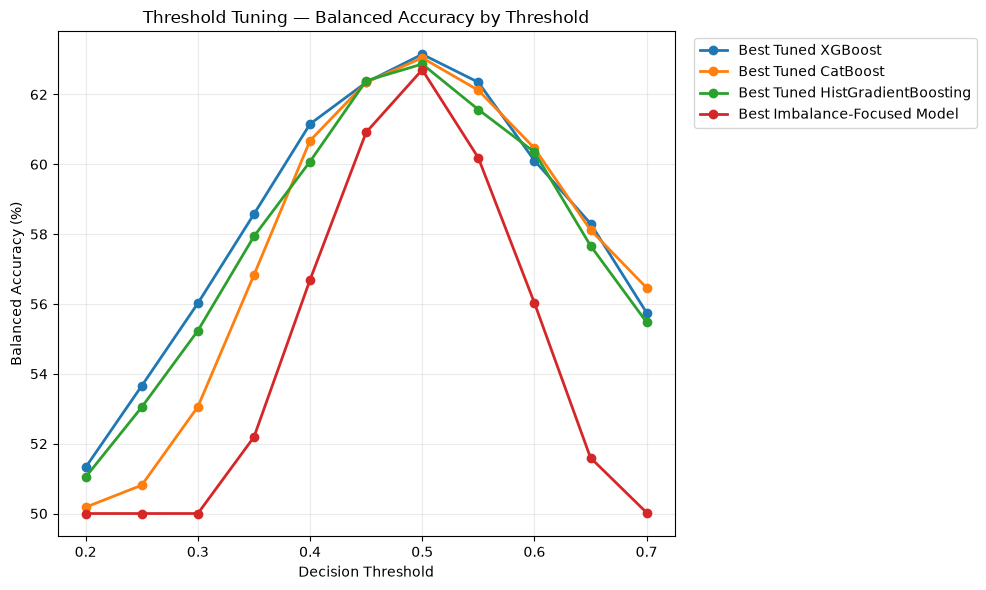

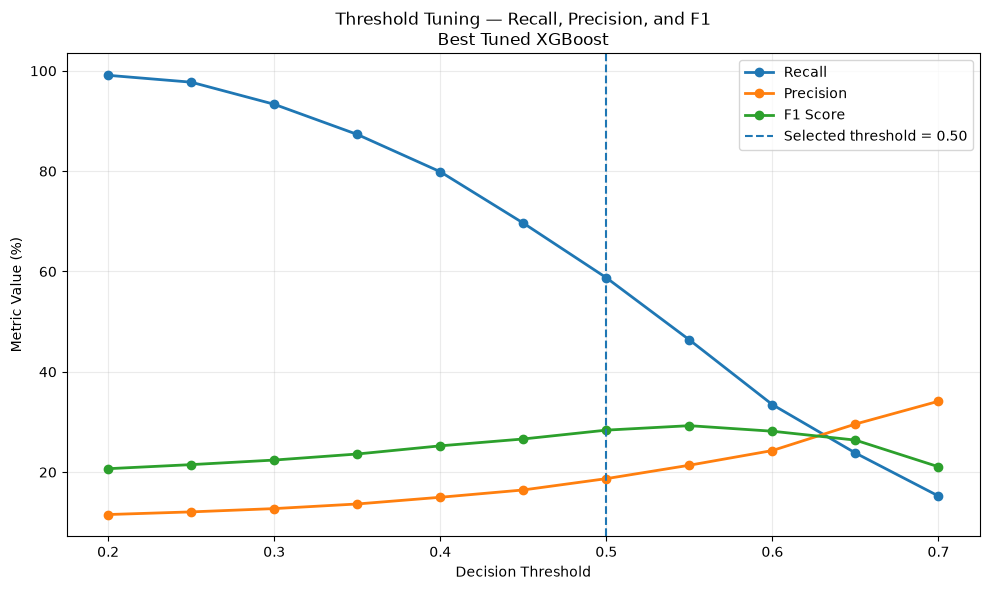

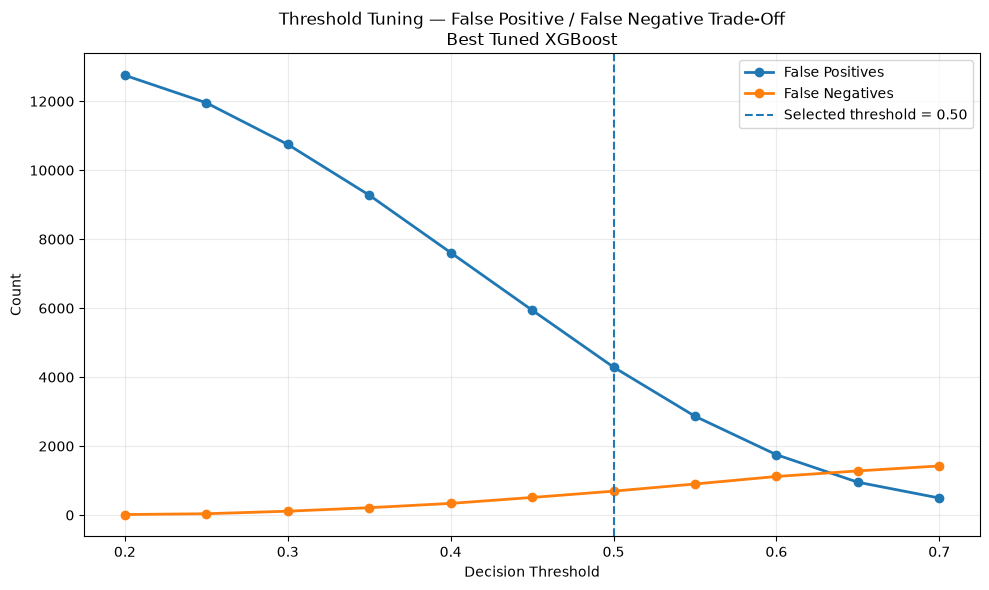

Threshold tuning outputs saved successfully.
--------------------------------------------------------------------------------

Saved metric files:
- C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_6_threshold_tuning_results.csv
- C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_6_best_threshold_by_model.csv
- C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_6_top_threshold_combinations.csv

Saved figures:
- C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_6_threshold_balanced_accuracy.png
- C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_6_threshold_recall_precision_f1.png
- C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_6_threshold_false_positive_false_negative_tradeoff.png

Selected model-threshold candidate:
Model: Best Tuned XGBoost
Threshold: 0.50

Selected candidate validation results:
accuracy     

In [11]:
# Step 9: Save threshold results and create threshold trade-off charts

from pathlib import Path
import matplotlib.pyplot as plt

# 1. Create output folders

METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"

METRICS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# 2. Define saved output paths

threshold_results_save_path = (
    METRICS_PATH
    / "notebook_6_threshold_tuning_results.csv"
)

best_threshold_by_model_save_path = (
    METRICS_PATH
    / "notebook_6_best_threshold_by_model.csv"
)

top_threshold_combinations_save_path = (
    METRICS_PATH
    / "notebook_6_top_threshold_combinations.csv"
)

balanced_accuracy_chart_path = (
    FIGURES_PATH
    / "notebook_6_threshold_balanced_accuracy.png"
)

recall_precision_chart_path = (
    FIGURES_PATH
    / "notebook_6_threshold_recall_precision_f1.png"
)

error_tradeoff_chart_path = (
    FIGURES_PATH
    / "notebook_6_threshold_false_positive_false_negative_tradeoff.png"
)

# 3. Save threshold result tables

threshold_tuning_results.to_csv(
    threshold_results_save_path,
    index=False
)

best_threshold_by_model.to_csv(
    best_threshold_by_model_save_path,
    index=False
)

top_threshold_combinations.to_csv(
    top_threshold_combinations_save_path,
    index=False
)

# 4. Plot balanced accuracy across thresholds

fig, ax = plt.subplots(figsize=(10, 6))

for model_name in threshold_tuning_results["model"].unique():

    model_results = threshold_tuning_results[
        threshold_tuning_results["model"] == model_name
    ].sort_values("threshold")

    ax.plot(
        model_results["threshold"],
        model_results["balanced_accuracy"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

ax.set_title("Threshold Tuning — Balanced Accuracy by Threshold")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Balanced Accuracy (%)")
ax.grid(alpha=0.25)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    balanced_accuracy_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Plot recall, precision, and F1 for selected leading model

leading_model_threshold_results = threshold_tuning_results[
    threshold_tuning_results["model"] == selected_model_name
].sort_values("threshold")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    leading_model_threshold_results["threshold"],
    leading_model_threshold_results["recall_sensitivity"] * 100,
    marker="o",
    linewidth=2,
    label="Recall"
)

ax.plot(
    leading_model_threshold_results["threshold"],
    leading_model_threshold_results["precision"] * 100,
    marker="o",
    linewidth=2,
    label="Precision"
)

ax.plot(
    leading_model_threshold_results["threshold"],
    leading_model_threshold_results["f1_score"] * 100,
    marker="o",
    linewidth=2,
    label="F1 Score"
)

ax.axvline(
    x=selected_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Selected threshold = {selected_threshold:.2f}"
)

ax.set_title(
    f"Threshold Tuning — Recall, Precision, and F1\n{selected_model_name}"
)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric Value (%)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    recall_precision_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Plot false positives and false negatives for selected model

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    leading_model_threshold_results["threshold"],
    leading_model_threshold_results["false_positives"],
    marker="o",
    linewidth=2,
    label="False Positives"
)

ax.plot(
    leading_model_threshold_results["threshold"],
    leading_model_threshold_results["false_negatives"],
    marker="o",
    linewidth=2,
    label="False Negatives"
)

ax.axvline(
    x=selected_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Selected threshold = {selected_threshold:.2f}"
)

ax.set_title(
    f"Threshold Tuning — False Positive / False Negative Trade-Off\n{selected_model_name}"
)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Count")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    error_tradeoff_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 7. Display confirmation

print("Threshold tuning outputs saved successfully.")
print("-" * 80)

print("\nSaved metric files:")
print(f"- {threshold_results_save_path}")
print(f"- {best_threshold_by_model_save_path}")
print(f"- {top_threshold_combinations_save_path}")

print("\nSaved figures:")
print(f"- {balanced_accuracy_chart_path}")
print(f"- {recall_precision_chart_path}")
print(f"- {error_tradeoff_chart_path}")

print("\nSelected model-threshold candidate:")
print(f"Model: {selected_model_name}")
print(f"Threshold: {selected_threshold:.2f}")

print("\nSelected candidate validation results:")
print(
    selected_threshold_row[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "false_positives",
            "false_negatives",
            "true_positives",
            "predicted_positive_rate",
        ]
    ]
    .round(4)
    .to_string()
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Threshold plots use validation data only.")

In [12]:
# Step 10: Save final tuned candidate model and metadata

import json
import joblib
from datetime import datetime

# 1. Create output directories

MODELS_PATH = PROJECT_ROOT / "models"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# 2. Define output paths

tuned_model_comparison_save_path = (
    METRICS_PATH
    / "notebook_6_tuned_model_comparison.csv"
)

xgboost_tuning_results_save_path = (
    METRICS_PATH
    / "notebook_6_xgboost_tuning_results.csv"
)

catboost_tuning_results_save_path = (
    METRICS_PATH
    / "notebook_6_catboost_tuning_results.csv"
)

hgb_tuning_results_save_path = (
    METRICS_PATH
    / "notebook_6_hist_gradient_boosting_tuning_results.csv"
)

imbalance_results_save_path = (
    METRICS_PATH
    / "notebook_6_imbalance_model_results.csv"
)

metadata_save_path = (
    ARTIFACTS_PATH
    / "notebook_6_model_tuning_threshold_metadata.json"
)

completion_summary_path = (
    METRICS_PATH
    / "notebook_6_completion_summary.csv"
)

selected_model_joblib_path = (
    MODELS_PATH
    / "notebook_6_selected_final_candidate_model.joblib"
)

best_xgboost_joblib_path = (
    MODELS_PATH
    / "notebook_6_best_tuned_xgboost.joblib"
)

best_xgboost_native_path = (
    MODELS_PATH
    / "notebook_6_best_tuned_xgboost.json"
)

best_catboost_native_path = (
    MODELS_PATH
    / "notebook_6_best_tuned_catboost.cbm"
)

best_hgb_joblib_path = (
    MODELS_PATH
    / "notebook_6_best_tuned_hist_gradient_boosting.joblib"
)

best_imbalance_joblib_path = (
    MODELS_PATH
    / "notebook_6_best_imbalance_focused_model.joblib"
)

# 3. Save result tables

tuned_model_comparison.to_csv(
    tuned_model_comparison_save_path,
    index=False
)

xgboost_tuning_results.to_csv(
    xgboost_tuning_results_save_path,
    index=False
)

catboost_tuning_results.to_csv(
    catboost_tuning_results_save_path,
    index=False
)

hgb_tuning_results.to_csv(
    hgb_tuning_results_save_path,
    index=False
)

imbalance_model_results.to_csv(
    imbalance_results_save_path,
    index=False
)

# 4. Save best tuned model objects

joblib.dump(
    best_xgboost_model,
    best_xgboost_joblib_path
)

best_xgboost_model.save_model(
    best_xgboost_native_path
)

best_catboost_model.save_model(
    best_catboost_native_path
)

joblib.dump(
    best_hgb_model,
    best_hgb_joblib_path
)

joblib.dump(
    best_imbalance_model,
    best_imbalance_joblib_path
)

# 5. Save selected final candidate model object

if selected_model_name == "Best Tuned XGBoost":
    selected_model_object = best_xgboost_model
    selected_model_type = "XGBoost"
    selected_model_config = best_xgboost_config_name

elif selected_model_name == "Best Tuned CatBoost":
    selected_model_object = best_catboost_model
    selected_model_type = "CatBoost"
    selected_model_config = best_catboost_config_name

elif selected_model_name == "Best Tuned HistGradientBoosting":
    selected_model_object = best_hgb_model
    selected_model_type = "HistGradientBoosting"
    selected_model_config = best_hgb_config_name

elif selected_model_name == "Best Imbalance-Focused Model":
    selected_model_object = best_imbalance_model
    selected_model_type = best_imbalance_model_name
    selected_model_config = best_imbalance_model_name

else:
    raise ValueError(
        f"Unknown selected model name: {selected_model_name}"
    )

joblib.dump(
    selected_model_object,
    selected_model_joblib_path
)

# 6. Create selected candidate summary

selected_candidate_summary = {
    "selected_model_name": selected_model_name,
    "selected_model_type": selected_model_type,
    "selected_model_config": selected_model_config,
    "selected_threshold": selected_threshold,
    "accuracy": float(selected_threshold_row["accuracy"]),
    "balanced_accuracy": float(selected_threshold_row["balanced_accuracy"]),
    "precision": float(selected_threshold_row["precision"]),
    "recall_sensitivity": float(selected_threshold_row["recall_sensitivity"]),
    "specificity": float(selected_threshold_row["specificity"]),
    "f1_score": float(selected_threshold_row["f1_score"]),
    "roc_auc": float(selected_threshold_row["roc_auc"]),
    "pr_auc": float(selected_threshold_row["pr_auc"]),
    "false_positives": int(selected_threshold_row["false_positives"]),
    "false_negatives": int(selected_threshold_row["false_negatives"]),
    "true_positives": int(selected_threshold_row["true_positives"]),
    "true_negatives": int(selected_threshold_row["true_negatives"]),
    "predicted_positive_rate": float(
        selected_threshold_row["predicted_positive_rate"]
    ),
}

# 7. Create Notebook 6 metadata

notebook_6_metadata = {
    "notebook": "06_model_tuning_threshold_selection.ipynb",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "target_column": TARGET_COLUMN,
    "group_column": GROUP_COLUMN,
    "raw_feature_count": len(MODEL_FEATURES),
    "transformed_feature_count": EXPECTED_TRANSFORMED_FEATURES,
    "train_encounters": int(len(train_df)),
    "validation_encounters": int(len(validation_df)),
    "reserved_test_encounters": int(len(test_df)),
    "test_set_used": False,
    "models_tuned": [
        "XGBoost",
        "CatBoost",
        "HistGradientBoosting",
        "Balanced Random Forest",
        "EasyEnsemble",
    ],
    "thresholds_tested": [
        float(threshold)
        for threshold in thresholds_to_test
    ],
    "selected_candidate": selected_candidate_summary,
    "selection_basis": [
        "balanced_accuracy",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "false_negatives",
        "false_positives",
    ],
    "saved_files": {
        "selected_model_joblib": str(selected_model_joblib_path),
        "best_xgboost_joblib": str(best_xgboost_joblib_path),
        "best_xgboost_native": str(best_xgboost_native_path),
        "best_catboost_native": str(best_catboost_native_path),
        "best_hist_gradient_boosting_joblib": str(best_hgb_joblib_path),
        "best_imbalance_focused_model_joblib": str(best_imbalance_joblib_path),
        "tuned_model_comparison": str(tuned_model_comparison_save_path),
        "xgboost_tuning_results": str(xgboost_tuning_results_save_path),
        "catboost_tuning_results": str(catboost_tuning_results_save_path),
        "hist_gradient_boosting_tuning_results": str(hgb_tuning_results_save_path),
        "imbalance_model_results": str(imbalance_results_save_path),
        "threshold_tuning_results": str(threshold_results_save_path),
        "best_threshold_by_model": str(best_threshold_by_model_save_path),
        "top_threshold_combinations": str(top_threshold_combinations_save_path),
        "metadata": str(metadata_save_path),
        "completion_summary": str(completion_summary_path),
    },
}

with open(
    metadata_save_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        notebook_6_metadata,
        file,
        indent=4
    )

# 8. Save compact completion summary

completion_summary = pd.DataFrame(
    [
        {
            "notebook": "06_model_tuning_threshold_selection.ipynb",
            "status": "Complete",
            "selected_model_name": selected_model_name,
            "selected_model_type": selected_model_type,
            "selected_model_config": selected_model_config,
            "selected_threshold": selected_threshold,
            "selected_accuracy": float(
                selected_threshold_row["accuracy"]
            ),
            "selected_balanced_accuracy": float(
                selected_threshold_row["balanced_accuracy"]
            ),
            "selected_precision": float(
                selected_threshold_row["precision"]
            ),
            "selected_recall": float(
                selected_threshold_row["recall_sensitivity"]
            ),
            "selected_specificity": float(
                selected_threshold_row["specificity"]
            ),
            "selected_f1_score": float(
                selected_threshold_row["f1_score"]
            ),
            "selected_roc_auc": float(
                selected_threshold_row["roc_auc"]
            ),
            "selected_pr_auc": float(
                selected_threshold_row["pr_auc"]
            ),
            "selected_false_positives": int(
                selected_threshold_row["false_positives"]
            ),
            "selected_false_negatives": int(
                selected_threshold_row["false_negatives"]
            ),
            "selected_true_positives": int(
                selected_threshold_row["true_positives"]
            ),
            "test_set_used": False,
        }
    ]
)

completion_summary.to_csv(
    completion_summary_path,
    index=False
)

# 9. Confirm important outputs exist

saved_paths = [
    selected_model_joblib_path,
    best_xgboost_joblib_path,
    best_xgboost_native_path,
    best_catboost_native_path,
    best_hgb_joblib_path,
    best_imbalance_joblib_path,
    tuned_model_comparison_save_path,
    xgboost_tuning_results_save_path,
    catboost_tuning_results_save_path,
    hgb_tuning_results_save_path,
    imbalance_results_save_path,
    threshold_results_save_path,
    best_threshold_by_model_save_path,
    top_threshold_combinations_save_path,
    metadata_save_path,
    completion_summary_path,
]

missing_saved_files = [
    str(path)
    for path in saved_paths
    if not path.exists()
]

if missing_saved_files:
    raise FileNotFoundError(
        "Some Notebook 6 outputs were not saved:\n"
        + "\n".join(missing_saved_files)
    )

# 10. Display completion information

print("Notebook 6 artifacts saved successfully.")
print("-" * 80)

print("\nSelected final validation candidate:")
print(f"Model name: {selected_model_name}")
print(f"Model type: {selected_model_type}")
print(f"Model configuration: {selected_model_config}")
print(f"Selected threshold: {selected_threshold:.2f}")

print("\nSelected candidate validation results:")
print(f"Accuracy: {selected_threshold_row['accuracy']:.4f}")
print(f"Balanced accuracy: {selected_threshold_row['balanced_accuracy']:.4f}")
print(f"Precision: {selected_threshold_row['precision']:.4f}")
print(f"Recall: {selected_threshold_row['recall_sensitivity']:.4f}")
print(f"Specificity: {selected_threshold_row['specificity']:.4f}")
print(f"F1 score: {selected_threshold_row['f1_score']:.4f}")
print(f"ROC-AUC: {selected_threshold_row['roc_auc']:.4f}")
print(f"PR-AUC: {selected_threshold_row['pr_auc']:.4f}")
print(f"False positives: {int(selected_threshold_row['false_positives'])}")
print(f"False negatives: {int(selected_threshold_row['false_negatives'])}")
print(f"True positives: {int(selected_threshold_row['true_positives'])}")

print("\nSaved model files:")
print(f"- {selected_model_joblib_path}")
print(f"- {best_xgboost_joblib_path}")
print(f"- {best_xgboost_native_path}")
print(f"- {best_catboost_native_path}")
print(f"- {best_hgb_joblib_path}")
print(f"- {best_imbalance_joblib_path}")

print("\nSaved metric and metadata files:")
print(f"- {tuned_model_comparison_save_path}")
print(f"- {metadata_save_path}")
print(f"- {completion_summary_path}")

print("\nNotebook 6 status:")
print("- Model tuning completed.")
print("- Threshold selection completed.")
print("- Selected final validation candidate saved.")
print("- Test set remains completely untouched.")

Notebook 6 artifacts saved successfully.
--------------------------------------------------------------------------------

Selected final validation candidate:
Model name: Best Tuned XGBoost
Model type: XGBoost
Model configuration: XGB_03_Deeper_Trees
Selected threshold: 0.50

Selected candidate validation results:
Accuracy: 0.6656
Balanced accuracy: 0.6315
Precision: 0.1870
Recall: 0.5875
Specificity: 0.6755
F1 score: 0.2837
ROC-AUC: 0.6807
PR-AUC: 0.2411
False positives: 4290
False negatives: 693
True positives: 987

Saved model files:
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_6_selected_final_candidate_model.joblib
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_6_best_tuned_xgboost.joblib
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_6_best_tuned_xgboost.json
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_6_best_tuned_catboost.cbm
- C:\Users\pradh\Documents\hospital-readmission-